In [1]:
#!/usr/bin/env python3

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd

# ==============================================================================
# Configuration
# ==============================================================================

SEARCH_CONFIGS = [
    # {
    #     "name": "Proxy lr1e-2 LL",
    #     "base_path": "/home/boat/proxyISP/pytorch-superpoint/eval_sweep/eval_DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_lowlight_lr0.01_bothLoss_initialHypeHomoAdaptOnly_gradac32",
    #     "pattern": re.compile(
    #         r"eval_sl_DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_lowlight_lr0.01_bothLoss_initialHypeHomoAdaptOnly_gradac32_(\d+)_HPatchesV4.1"
    #     ),
    #     "checkpoint_dir": "/home/boat/proxyISP/pytorch-superpoint/logs/DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_lowlight_lr0.01_bothLoss_initialHypeHomoAdaptOnly_gradac32/proxyopt_checkpoints"
    # },

    {
        "name": "Proxy lr1e-2 sl gradac32 dl5.0",
        "base_path": "/home/boat/proxyISP/pytorch-superpoint/eval_sweep/eval_DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlit_lr0.01_bothLoss_initialHypeHomoAdaptOnly_gradac32",
        "pattern": re.compile(
            r"eval_sl_DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlit_lr0.01_bothLoss_initialHypeHomoAdaptOnly_gradac32_(\d+)_HPatchesV4.1"
        ),
        "checkpoint_dir": "/home/boat/proxyISP/pytorch-superpoint/logs/DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlit_lr0.01_bothLoss_initialHypeHomoAdaptOnly_gradac32/proxyopt_checkpoints"
    },
    {
        "name": "Proxy lr5e-4 sl gradac32 dl5.0",
        "base_path": "/home/boat/proxyISP/pytorch-superpoint/eval_sweep/eval_DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlit_lr0.0005_bothLoss_initialHypeHomoAdaptOnly_gradac32",
        "pattern": re.compile(
            r"eval_sl_DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlit_lr0.0005_bothLoss_initialHypeHomoAdaptOnly_gradac32_(\d+)_HPatchesV4.1"
        ),
        "checkpoint_dir": "/home/boat/proxyISP/pytorch-superpoint/logs/DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlit_lr0.0005_bothLoss_initialHypeHomoAdaptOnly_gradac32/proxyopt_checkpoints"
    },
    {
        "name": "Proxy lr1e-2 slhpatches gradac32 dl5.0",
        "base_path": "/home/boat/proxyISP/pytorch-superpoint/eval_sweep/eval_DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlithpatchesv4.1_lr0.01_bothLoss_initialHypeHomoAdaptOnly_gradac32",
        "pattern": re.compile(
            r"eval_sl_DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlithpatchesv4.1_lr0.01_bothLoss_initialHypeHomoAdaptOnly_gradac32_(\d+)_HPatchesV4.1"
        ),
        "checkpoint_dir": "/home/boat/proxyISP/pytorch-superpoint/logs/DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlithpatchesv4.1_lr0.01_bothLoss_initialHypeHomoAdaptOnly_gradac32/proxyopt_checkpoints"
    },
    {
        "name": "Proxy lr5e-3 gradac187 dl1.0",
        "base_path": "/home/boat/proxyISP/pytorch-superpoint/logs",
        "pattern": re.compile(
            r"eval_sl_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlit_lr0.005_bothLoss_initialHypeHomoAdaptOnly_gradac187_(\d+)_HPatchesV4.1"
        ),
        "checkpoint_dir": "/home/boat/proxyISP/pytorch-superpoint/logs/PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlit_lr0.005_bothLoss_initialHypeHomoAdaptOnly_gradac187/proxyopt_checkpoints"
    },
    {
        "name": "Proxy lr5e-3 gradac187 dl5.0",
        "base_path": "/home/boat/proxyISP/pytorch-superpoint/logs",
        "pattern": re.compile(
            r"eval_sl_DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlit_lr0.005_bothLoss_initialHypeHomoAdaptOnly_gradac187_(\d+)_HPatchesV4.1"
        ),
        "checkpoint_dir": "/home/boat/proxyISP/pytorch-superpoint/logs/DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlit_lr0.005_bothLoss_initialHypeHomoAdaptOnly_gradac187/proxyopt_checkpoints"
    },
    {
        "name": "Proxy lr5e-3 gradac32 dl1.0",
        "base_path": "/home/boat/proxyISP/pytorch-superpoint/logs",
        "pattern": re.compile(
            r"eval_sl_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlit_lr0.005_bothLoss_initialHypeHomoAdaptOnly_gradac32_(\d+)_HPatchesV4.1"
        ),
        "checkpoint_dir": "/home/boat/proxyISP/pytorch-superpoint/logs/PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_CFANORMALIZE_XHOMOWARP_DETERMHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_sunlit_lr0.005_bothLoss_initialHypeHomoAdaptOnly_gradac32/proxyopt_checkpoints"
    },
    {
        "name": "cma 0.01 dl1.0",
        "base_path": "/home/boat/proxyISP/pytorch-superpoint/logs",
        "pattern": re.compile(
            r"eval_sl_CMAES_train_sunlit_maxstd0.01_(\d+)_HPatchesV4.1"
        ),
        "checkpoint_dir": "/home/boat/proxyISP/pytorch-superpoint/logs/CMAES_train_sunlit_maxstd0.01/cma_es_checkpoints"
    },



    # -------------------------------------------------------------------------
    # Add more experiments here
    # -------------------------------------------------------------------------

    # {
    #     "name": "Proxy lr1e-2",
    #     "base_path": "...",
    #     "pattern": re.compile(
    #         r"..._(\d+)_HPatchesV4\.1"
    #     ),
    #     "checkpoint_dir": "...",
    # },

    # {
    #     "name": "CMA-ES",
    #     "base_path": "...",
    #     "pattern": re.compile(
    #         r"..._(\d+)_HPatchesV4\.1"
    #     ),
    #     "checkpoint_dir": "...",
    # },
]

RESULT_FILENAME = os.path.join("predictions", "result.npz")


# ==============================================================================
# Helper
# ==============================================================================

def estimate_sec_per_iter(eval_dirs):
    """
    Estimate median seconds/iteration using checkpoint timestamps.
    """

    eval_dirs = sorted(eval_dirs, key=lambda x: x["iter"])

    sec_per_iter = []

    for prev, cur in zip(eval_dirs[:-1], eval_dirs[1:]):

        prev_ckpt = Path(prev["checkpoint_path"])
        cur_ckpt = Path(cur["checkpoint_path"])

        if not prev_ckpt.exists():
            continue

        if not cur_ckpt.exists():
            continue

        prev_time = prev_ckpt.stat().st_mtime
        cur_time = cur_ckpt.stat().st_mtime

        dt = cur_time - prev_time
        diter = cur["iter"] - prev["iter"]

        if diter <= 0:
            continue

        if dt <= 0:
            continue

        sec_per_iter.append(dt / diter)

    if len(sec_per_iter) == 0:
        return np.nan

    return float(np.median(sec_per_iter))


# ==============================================================================
# Step 1 : Find evaluation directories
# ==============================================================================

eval_dirs = []

for cfg in SEARCH_CONFIGS:

    if not os.path.isdir(cfg["base_path"]):
        print(f"[WARN] Missing base path: {cfg['base_path']}")
        continue

    for dirname in os.listdir(cfg["base_path"]):

        full_dir = os.path.join(cfg["base_path"], dirname)

        if not os.path.isdir(full_dir):
            continue

        m = cfg["pattern"].match(dirname)

        if m is None:
            continue

        iteration = int(m.group(1))

        result_path = os.path.join(full_dir, RESULT_FILENAME)

        if not os.path.exists(result_path):
            continue

        checkpoint_path = os.path.join(
            cfg["checkpoint_dir"],
            f"checkpoint_{iteration}.pkl"
        )

        eval_dirs.append(
            {
                "experiment": cfg["name"],
                "iter": iteration,
                "dir_name": dirname,
                "result_path": result_path,
                "checkpoint_path": checkpoint_path,
            }
        )

if len(eval_dirs) == 0:
    raise RuntimeError("No matching evaluation directories found.")


# ==============================================================================
# Step 2 : Estimate runtime for each experiment
# ==============================================================================

experiment_sec_per_iter = {}
experiment_first_iter = {}

for exp in sorted(set(d["experiment"] for d in eval_dirs)):

    dirs = [
        d
        for d in eval_dirs
        if d["experiment"] == exp
    ]

    dirs = sorted(
        dirs,
        key=lambda x: x["iter"]
    )

    experiment_first_iter[exp] = dirs[0]["iter"]

    experiment_sec_per_iter[exp] = estimate_sec_per_iter(dirs)

    sec = experiment_sec_per_iter[exp]

    if np.isnan(sec):
        print(f"{exp:25s} timing unavailable")
    else:
        print(
            f"{exp:25s}"
            f"{sec:8.2f} sec/iter"
            f" ({3600/sec:8.1f} iter/hour)"
        )

rows = []

# ==============================================================================
# Step 3 : Load SuperPoint metrics
# ==============================================================================

for item in sorted(eval_dirs, key=lambda x: (x["experiment"], x["iter"])):

    data = np.load(item["result_path"])

    correctness = data["correctness"]

    repeatability = (
        data["repeatability"]
        if "repeatability" in data.files
        else None
    )

    mscore = (
        data["mscore"]
        if "mscore" in data.files
        else None
    )

    mAP = (
        data["mAP"]
        if "mAP" in data.files
        else None
    )

    loc_err = (
        data["localization_err"]
        if "localization_err" in data.files
        else None
    )

    # ----------------------------------------------------------
    # Homography correctness
    # ----------------------------------------------------------

    thresh_means = correctness.mean(axis=0)

    avg_correctness = thresh_means.mean()

    # ----------------------------------------------------------
    # Timing
    # ----------------------------------------------------------

    sec_per_iter = experiment_sec_per_iter[item["experiment"]]

    if np.isnan(sec_per_iter):
        elapsed_seconds = np.nan
    else:
        elapsed_seconds = (
            item["iter"]
            - experiment_first_iter[item["experiment"]]
        ) * sec_per_iter

    # ----------------------------------------------------------
    # Store row
    # ----------------------------------------------------------

    rows.append(
        {
            "experiment": item["experiment"],
            "iter": item["iter"],

            "elapsed_seconds": elapsed_seconds,
            "elapsed_minutes": (
                elapsed_seconds / 60
                if not np.isnan(elapsed_seconds)
                else np.nan
            ),
            "elapsed_hours": (
                elapsed_seconds / 3600
                if not np.isnan(elapsed_seconds)
                else np.nan
            ),

            "sec_per_iter": sec_per_iter,

            "dir_name": item["dir_name"],

            # correctness
            "t1": thresh_means[0],
            "t2": thresh_means[1],
            "t3": thresh_means[2],
            "t4": thresh_means[3],
            "t5": thresh_means[4],
            "t6": thresh_means[5],

            "avg": avg_correctness,

            # SuperPoint metrics
            "mean_repeat":
                np.mean(repeatability)
                if repeatability is not None
                else np.nan,

            "mean_mscore":
                np.mean(mscore)
                if mscore is not None
                else np.nan,

            "mean_map":
                np.mean(mAP)
                if mAP is not None
                else np.nan,

            "mean_loc_err":
                np.mean(loc_err)
                if loc_err is not None
                else np.nan,
        }
    )

# ==============================================================================
# Step 4 : Build dataframe
# ==============================================================================

df = pd.DataFrame(rows)

df = df.sort_values(
    ["experiment", "iter"]
).reset_index(drop=True)

print("\n==============================")
print("All checkpoints")
print("==============================")

print(df)

# ==============================================================================
# Best checkpoint (Correctness)
# ==============================================================================

best_correctness = (
    df.sort_values(
        "avg",
        ascending=False
    )
    .groupby(
        "experiment",
        as_index=False
    )
    .first()
)

print("\n==============================")
print("Best checkpoint by correctness")
print("==============================")

print(
    best_correctness[
        [
            "experiment",
            "iter",
            "elapsed_hours",
            "avg",
            "t1",
            "t2",
            "t3",
            "t4",
            "t5",
            "t6",
            "mean_repeat",
            "mean_mscore",
            "mean_map",
            "mean_loc_err",
        ]
    ]
)

# ==============================================================================
# Best checkpoint (Localization Error)
# ==============================================================================

if "mean_loc_err" in df.columns:

    best_loc = (
        df.sort_values(
            "mean_loc_err",
            ascending=True
        )
        .groupby(
            "experiment",
            as_index=False
        )
        .first()
    )

    print("\n==============================")
    print("Best checkpoint by localization error")
    print("==============================")

    print(
        best_loc[
            [
                "experiment",
                "iter",
                "elapsed_hours",
                "mean_loc_err",
                "avg",
                "mean_repeat",
                "mean_mscore",
                "mean_map",
            ]
        ]
    )

# ==============================================================================
# Optional CSV export
# ==============================================================================

df.to_csv(
    "superpoint_summary.csv",
    index=False
)

best_correctness.to_csv(
    "superpoint_best_correctness.csv",
    index=False
)

print("\nSaved:")
print("  superpoint_summary.csv")
print("  superpoint_best_correctness.csv")

Proxy lr1e-2 sl gradac32 dl5.0    0.77 sec/iter (  4645.4 iter/hour)
Proxy lr1e-2 slhpatches gradac32 dl5.0    0.79 sec/iter (  4553.8 iter/hour)
Proxy lr5e-3 gradac187 dl1.0    0.61 sec/iter (  5945.9 iter/hour)
Proxy lr5e-3 gradac187 dl5.0    0.79 sec/iter (  4574.8 iter/hour)
Proxy lr5e-3 gradac32 dl1.0    0.78 sec/iter (  4594.3 iter/hour)
Proxy lr5e-4 sl gradac32 dl5.0    0.79 sec/iter (  4567.1 iter/hour)
cma 0.01 dl1.0              21.85 sec/iter (   164.7 iter/hour)

All checkpoints
                         experiment  iter  elapsed_seconds  elapsed_minutes  \
0    Proxy lr1e-2 sl gradac32 dl5.0     0         0.000000         0.000000   
1    Proxy lr1e-2 sl gradac32 dl5.0  1000       774.956927        12.915949   
2    Proxy lr1e-2 sl gradac32 dl5.0  2000      1549.913855        25.831898   
3    Proxy lr1e-2 sl gradac32 dl5.0  3000      2324.870782        38.747846   
4    Proxy lr1e-2 sl gradac32 dl5.0  4000      3099.827710        51.663795   
..                            

In [2]:
pd.set_option('display.max_rows', None)

# Best checkpoint (highest average correctness) for each experiment
idx = df.groupby("experiment")["avg"].idxmax()

best_rows = df.loc[idx]

# Optional: sort experiments by best avg correctness
best_rows = best_rows.sort_values("avg", ascending=False)

display(best_rows)

,experiment,iter,elapsed_seconds,elapsed_minutes,elapsed_hours,sec_per_iter,dir_name,t1,t2,t3,t4,t5,t6,avg,mean_repeat,mean_mscore,mean_map,mean_loc_err
464,cma 0.01 dl1.0,330,6556.381072,109.273018,1.821217,21.854604,eval_sl_CMAES_train_sunlit_maxstd0.01_330_HPat...,0.300000,0.607143,0.692857,0.785714,0.835714,0.892857,0.685714,0.658688,0.355828,0.771616,1.013900
162,Proxy lr5e-3 gradac187 dl1.0,33000,19979.991386,332.999856,5.549998,0.605454,eval_sl_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSI...,0.342857,0.571429,0.685714,0.778571,0.850000,0.885714,0.685714,0.658159,0.354869,0.763469,1.013855
89,Proxy lr1e-2 slhpatches gradac32 dl5.0,8000,6324.426914,105.407115,1.756785,0.790553,eval_sl_DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMO...,0.307143,0.564286,0.685714,0.742857,0.857143,0.900000,0.676190,0.655655,0.352611,0.773437,1.020823
227,Proxy lr5e-3 gradac187 dl5.0,1000,786.925972,13.115433,0.218591,0.786926,eval_sl_DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMO...,0.314286,0.564286,0.692857,0.771429,0.814286,0.885714,0.673810,0.656637,0.352041,0.762772,1.015276
79,Proxy lr1e-2 sl gradac32 dl5.0,79000,61221.597266,1020.359954,17.005999,0.774957,eval_sl_DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMO...,0.292857,0.557143,0.678571,0.735714,0.842857,0.892857,0.666667,0.650789,0.347508,0.755655,1.031793
304,Proxy lr5e-3 gradac32 dl1.0,0,0.000000,0.000000,0.000000,0.783575,eval_sl_PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSI...,0.292857,0.564286,0.628571,0.778571,0.842857,0.878571,0.664286,0.656453,0.350599,0.769040,1.015394
378,Proxy lr5e-4 sl gradac32 dl5.0,0,0.000000,0.000000,0.000000,0.788246,eval_sl_DESCLAMBDA5.0_PRETRAINED_SAMEMODELHOMO...,0.292857,0.564286,0.628571,0.778571,0.842857,0.878571,0.664286,0.656453,0.350599,0.769040,1.015394


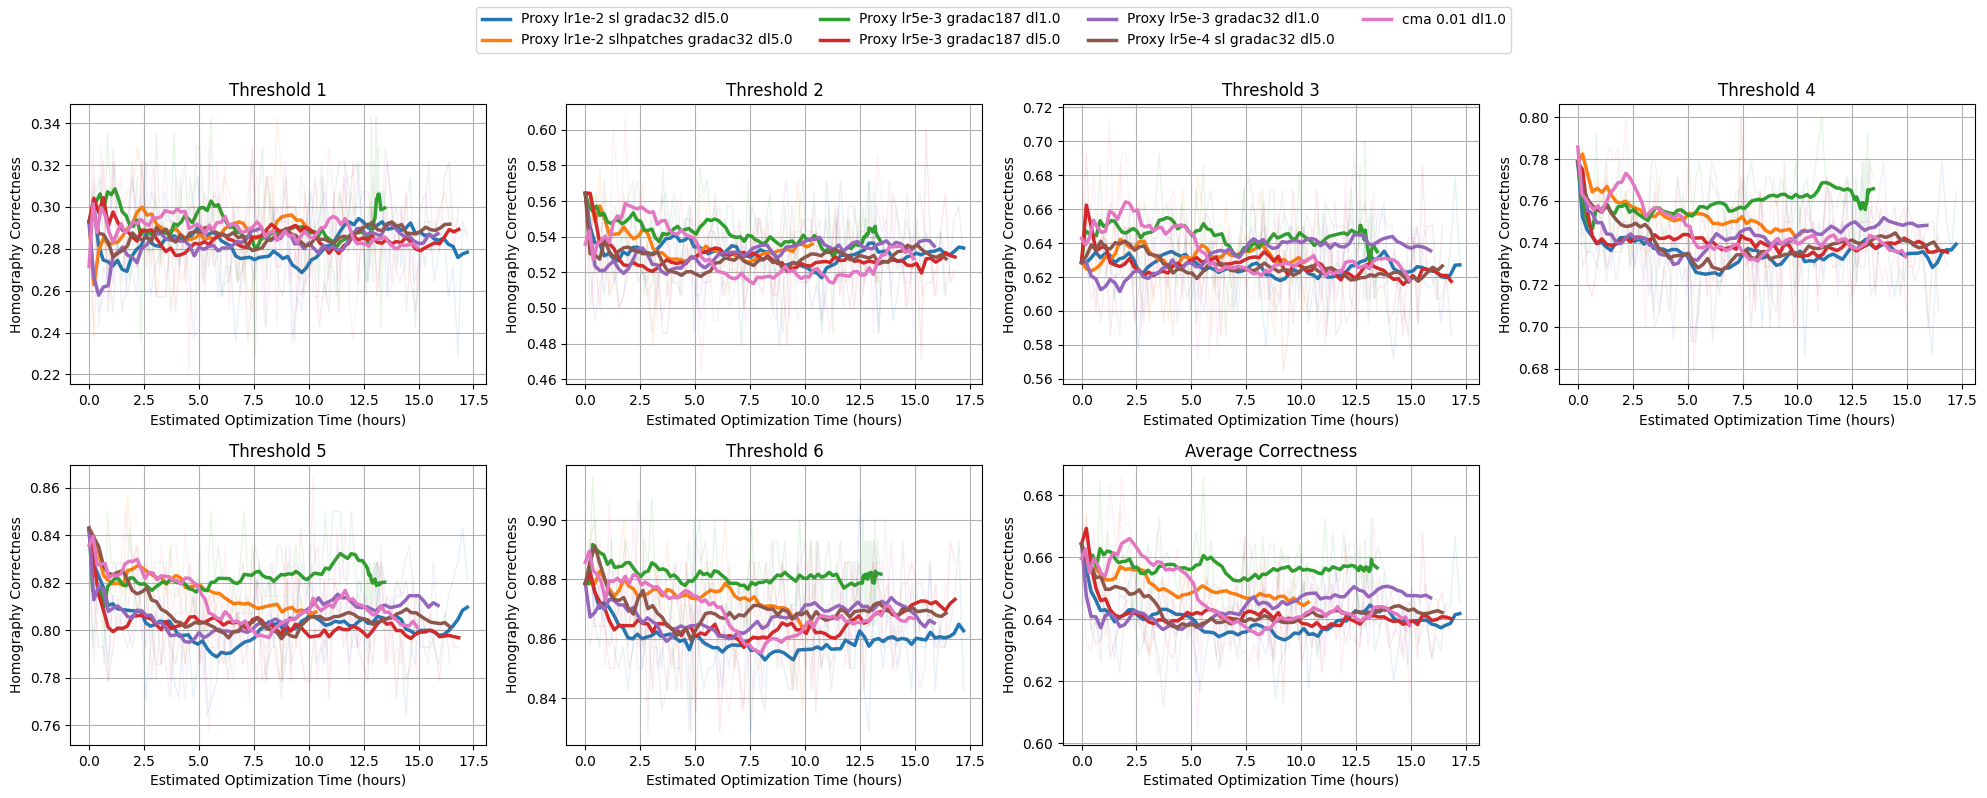

In [5]:
import matplotlib.pyplot as plt

alpha = 0.1

experiments = df["experiment"].unique()

threshold_cols = [f"t{i}" for i in range(1, 7)]

# 6 thresholds + average = 7 plots
nrows = 2
ncols = 4

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(20, 8),
    sharey=False
)

axes = axes.flatten()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_map = {
    exp: colors[i % len(colors)]
    for i, exp in enumerate(experiments)
}

# ------------------------------------------------------------------
# Plot thresholds
# ------------------------------------------------------------------

for i, col in enumerate(threshold_cols):

    ax = axes[i]

    for exp in experiments:

        d = (
            df[df["experiment"] == exp]
            .sort_values("elapsed_hours")
            .copy()
        )

        ema = d[col].ewm(alpha=alpha).mean()

        color = color_map[exp]

        # Raw curve
        ax.plot(
            d["elapsed_hours"],
            d[col],
            color=color,
            alpha=0.1,
            linewidth=1,
        )

        # EMA
        ax.plot(
            d["elapsed_hours"],
            ema,
            color=color,
            linewidth=2.5,
            label=exp,
        )

    ax.set_title(f"Threshold {i+1}")
    ax.set_xlabel("Estimated Optimization Time (hours)")
    ax.set_ylabel("Homography Correctness")
    ax.grid(True)

# ------------------------------------------------------------------
# Average subplot
# ------------------------------------------------------------------

ax = axes[6]

for exp in experiments:

    d = (
        df[df["experiment"] == exp]
        .sort_values("elapsed_hours")
        .copy()
    )

    ema = d["avg"].ewm(alpha=alpha).mean()

    color = color_map[exp]

    ax.plot(
        d["elapsed_hours"],
        d["avg"],
        color=color,
        alpha=0.1,
        linewidth=1,
    )

    ax.plot(
        d["elapsed_hours"],
        ema,
        color=color,
        linewidth=2.5,
        label=exp,
    )

ax.set_title("Average Correctness")
ax.set_xlabel("Estimated Optimization Time (hours)")
ax.set_ylabel("Homography Correctness")
ax.grid(True)

# Remove unused subplot
fig.delaxes(axes[7])

# ------------------------------------------------------------------
# Legend
# ------------------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    ncol=min(4, len(by_label)),
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig(
    "superpoint_correctness_time.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

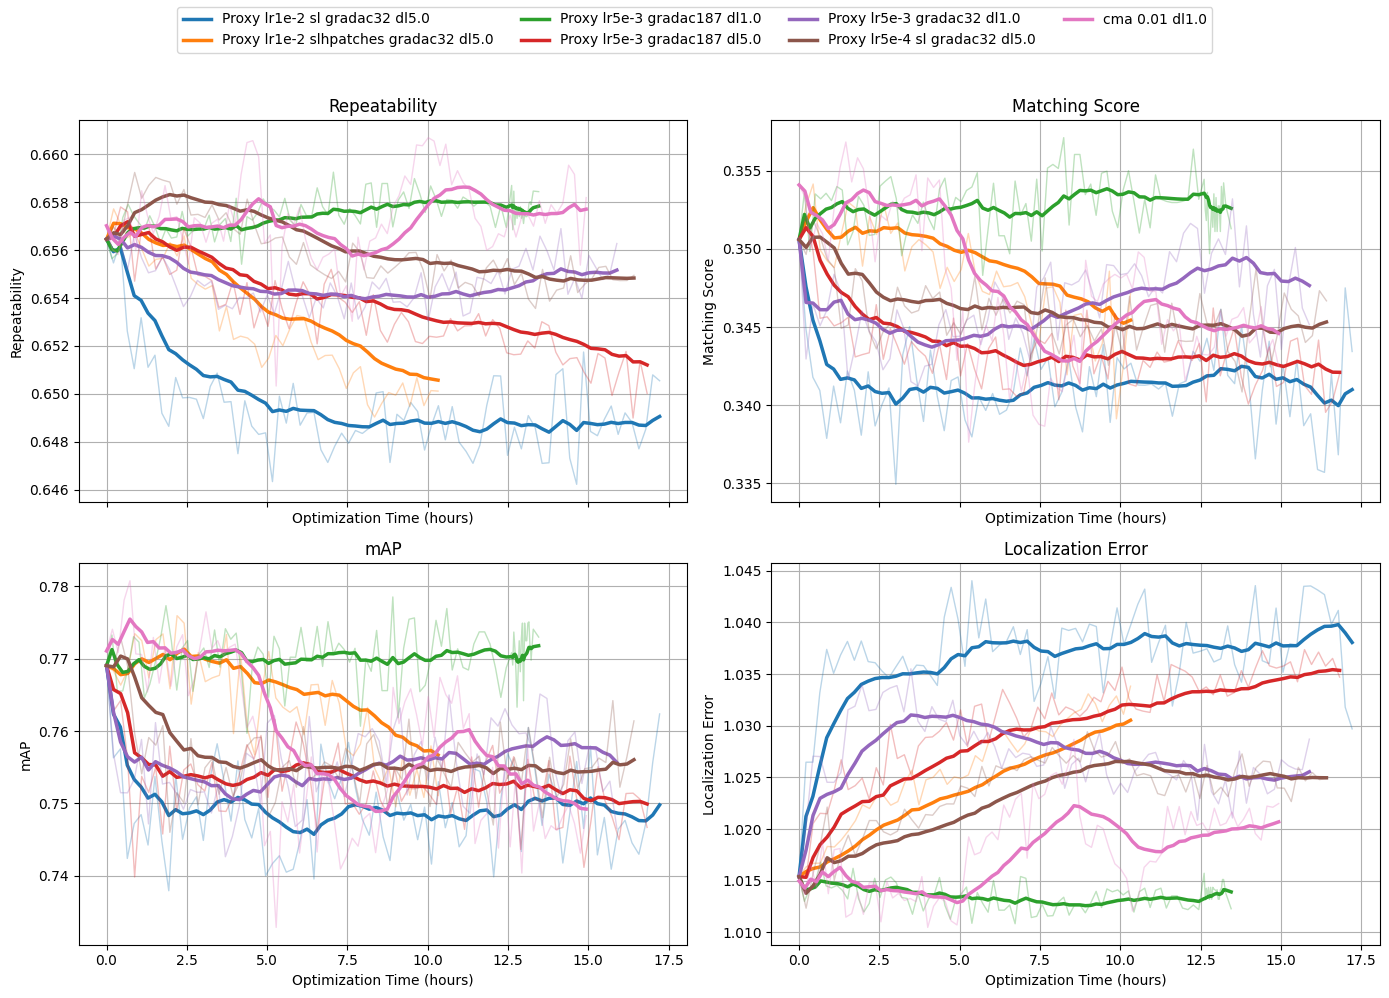

In [9]:
import matplotlib.pyplot as plt

alpha = 0.1

experiments = df["experiment"].unique()

metrics = [
    ("mean_repeat", "Repeatability"),
    ("mean_mscore", "Matching Score"),
    ("mean_map", "mAP"),
    ("mean_loc_err", "Localization Error"),
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10),
    sharex=True,
)

axes = axes.flatten()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_map = {
    exp: colors[i % len(colors)]
    for i, exp in enumerate(experiments)
}

for ax, (metric, title) in zip(axes, metrics):

    for exp in experiments:

        d = (
            df[df["experiment"] == exp]
            .sort_values("elapsed_hours")
            .copy()
        )

        ema = d[metric].ewm(alpha=alpha).mean()

        color = color_map[exp]

        # Raw curve
        ax.plot(
            d["elapsed_hours"],
            d[metric],
            color=color,
            alpha=0.3,
            linewidth=1,
        )

        # EMA curve
        ax.plot(
            d["elapsed_hours"],
            ema,
            color=color,
            linewidth=2.5,
            label=exp,
        )

    ax.set_title(title)
    ax.set_xlabel("Optimization Time (hours)")
    ax.set_ylabel(title)
    ax.grid(True)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    ncol=min(4, len(by_label)),
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig(
    "superpoint_metrics_time.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()